In [1]:
%load_ext autoreload
%autoreload 2

In [79]:
from fda_rof_funcs_v4 import TX, RX

params = {
    "Rt": 2.25,
    "k": 1.0,
    "para_N1": {"a": 2.0, "b": 4.0},
    "para_N2": {"a": 8, "b":2.6},
    "parabits_path": "parabits.mat",
}

tx_output = TX(params)
snr1, snr2, snr_total, ber = RX(tx_output, params)
print(snr1, snr2, snr_total, ber)

[0.00100937]
SNR of 1 symbols is 29.955113 dB
[4.88299132e-05]
SNR of 2 symbols is 43.112928 dB
[0.00076949]
SNR of t symbols is 31.134645 dB
BER = 3.332194e-01
29.955112654977448 43.112928406589994 31.134645321401667 0.33321940104166664


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fda_rof_funcs_v4 import TX, RX


PARABITS_PATH = "parabits.mat"   # 改成你的实际路径


def make_params(Rt, k, a1, b1, a2, b2, parabits_path=PARABITS_PATH):
    return {
        "Rt": Rt,
        "k": float(k),
        "para_N1": {"a": float(a1), "b": float(b1)},
        "para_N2": {"a": float(a2), "b": float(b2)},
        "parabits_path": parabits_path,
    }


def run_once(params, seed=None):
    if seed is not None:
        
        np.random.seed(seed)

    tx_output = TX(params)
    snr1, snr2, snr_total, ber = RX(tx_output, params)

    return {
        "Rt": params["Rt"],
        "k": params["k"],
        "a1": params["para_N1"]["a"],
        "b1": params["para_N1"]["b"],
        "a2": params["para_N2"]["a"],
        "b2": params["para_N2"]["b"],
        "snr1": snr1,
        "snr2": snr2,
        "snr_total": snr_total,
        "ber": ber,
    }


def run_avg(params, n_repeats=3, base_seed=1000):
    rows = []
    for i in range(n_repeats):
        rows.append(run_once(params, seed=base_seed + i))
    df = pd.DataFrame(rows)
    mean_rec = df.mean(numeric_only=True).to_dict()

    mean_rec["Rt"] = params["Rt"]
    mean_rec["k"] = params["k"]
    mean_rec["a1"] = params["para_N1"]["a"]
    mean_rec["b1"] = params["para_N1"]["b"]
    mean_rec["a2"] = params["para_N2"]["a"]
    mean_rec["b2"] = params["para_N2"]["b"]

    return mean_rec


def scan_a1_b1_lines(
    Rt,
    k,
    a2,
    b2,
    a1_range,
    b1_range,
    snr_key="snr1",      # 可选: "snr1", "snr2", "snr_total"
    n_repeats=3,
    parabits_path=PARABITS_PATH,
):
    rows = []

    for b1 in b1_range:
        for a1 in a1_range:
            params = make_params(
                Rt=Rt, k=k,
                a1=a1, b1=b1,
                a2=a2, b2=b2,
                parabits_path=parabits_path
            )
            rec = run_avg(params, n_repeats=n_repeats)
            rows.append(rec)

    df = pd.DataFrame(rows)
    return df


def plot_a1_b1_lines(
    df,
    snr_key="snr1",
    title=None,
):
    plt.figure(figsize=(7, 5))

    b1_values = sorted(df["b1"].unique())
    for b1 in b1_values:
        df_sub = df[df["b1"] == b1].sort_values("a1")
        plt.plot(
            df_sub["a1"],
            df_sub[snr_key],
            marker="o",
            label=f"b1={b1}"
        )

    plt.xlabel("a1")
    plt.ylabel(snr_key)
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def scan_a2_b2_lines(
    Rt,
    k,
    a1,
    b1,
    a2_range,
    b2_range,
    snr_key="snr2",      # 可选: "snr1", "snr2", "snr_total"
    n_repeats=3,
    parabits_path=PARABITS_PATH,
):
    rows = []

    for b2 in b2_range:
        for a2 in a2_range:
            params = make_params(
                Rt=Rt, k=k,
                a1=a1, b1=b1,
                a2=a2, b2=b2,
                parabits_path=parabits_path
            )
            rec = run_avg(params, n_repeats=n_repeats)
            rows.append(rec)

    df = pd.DataFrame(rows)
    return df


def plot_a2_b2_lines(
    df,
    snr_key="snr2",
    title=None,
):
    plt.figure(figsize=(7, 5))

    b2_values = sorted(df["b2"].unique())
    for b2 in b2_values:
        df_sub = df[df["b2"] == b2].sort_values("a2")
        plt.plot(
            df_sub["a2"],
            df_sub[snr_key],
            marker="o",
            label=f"b2={b2}"
        )

    plt.xlabel("a2")
    plt.ylabel(snr_key)
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def scan_total_SNR_k_lines(
    Rt,
    a1,
    b1,
    a2,
    b2,
    k_range,
    n_repeats=2,
    parabbits_path=PARABITS_PATH,
):
    rows = []

    for k in k_range:
        params = make_params(
            Rt=Rt, k=k,
            a1=a1, b1=b1,
            a2=a2, b2=b2,

        )
        rec = run_avg(params, n_repeats=n_repeats)
        rows.append(rec)

    df = pd.DataFrame(rows)
    return df
def plot_total_SNR_k_lines(
    df,
    title=None,
):
    plt.figure(figsize=(7, 5))

    k_values = sorted(df["k"].unique())
    for k in k_values:
        df_sub = df[df["k"] == k].sort_values("Rt")
        plt.plot(
            df_sub["k"],
            df_sub["snr_total"],
            marker="o",
            label=f"k={k}"
        )

    plt.xlabel("Power factor k")
    plt.ylabel("Total SNR (dB)")
    if title is not None:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
def plot_total_SNR_k_lines_by_Rt(df, title=None):
    import matplotlib.pyplot as plt
    df = df.copy()
    df['k'] = df['k'].astype(float)
    plt.figure(figsize=(7,5))

    for Rt in sorted(df['Rt'].unique()):
        df_sub = df[df['Rt'] == Rt].sort_values('k')
        if df_sub.shape[0] < 2:
            # 如果该 Rt 下只有一个点，仍然画出点（无连线）
            plt.plot(df_sub['k'], df_sub['snr_total'], marker='o', linestyle='', label=f'Rt={Rt}')
        else:
            plt.plot(df_sub['k'], df_sub['snr_total'], marker='o', linestyle='-', label=f'Rt={Rt}')

    plt.xlabel("Power factor k")
    plt.ylabel("Total SNR (dB)")
    if title:
        plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def print_best_per_b2(df, snr_key="snr2"):
    b2_values = sorted(df["b2"].unique())
    best_rows = []

    for b2 in b2_values:
        df_sub = df[df["b2"] == b2]
        idx = df_sub[snr_key].idxmax()
        best_rows.append(df_sub.loc[idx])

    best_df = pd.DataFrame(best_rows).reset_index(drop=True)
    print(best_df[["a2", "b2", snr_key]])
    return best_df

[0.00023045]
SNR of 1 symbols is 36.373278 dB
[0.00070686]
SNR of 2 symbols is 31.503617 dB
[0.00035715]
SNR of t symbols is 34.469926 dB
BER = 3.332194e-01
[0.00012666]
SNR of 1 symbols is 38.973056 dB
[0.0003541]
SNR of 2 symbols is 34.507228 dB
[0.00019076]
SNR of t symbols is 37.194249 dB
BER = 3.332194e-01
[4.12000035e-05]
SNR of 1 symbols is 43.850849 dB
[0.00070686]
SNR of 2 symbols is 31.503617 dB
[0.00021518]
SNR of t symbols is 36.670973 dB
BER = 3.332194e-01
[5.64599102e-05]
SNR of 1 symbols is 42.482353 dB
[0.00070686]
SNR of 2 symbols is 31.503617 dB
[0.00022739]
SNR of t symbols is 36.431208 dB
BER = 3.332194e-01
[0.00012971]
SNR of 1 symbols is 38.869624 dB
[0.00070533]
SNR of 2 symbols is 31.513019 dB
[0.00028235]
SNR of t symbols is 35.490936 dB
BER = 3.332194e-01
[0.00016939]
SNR of 1 symbols is 37.710282 dB
[0.00070686]
SNR of 2 symbols is 31.503617 dB
[0.00031135]
SNR of t symbols is 35.066131 dB
BER = 3.332194e-01
[0.00071908]
SNR of 1 symbols is 31.429125 dB
[0.00

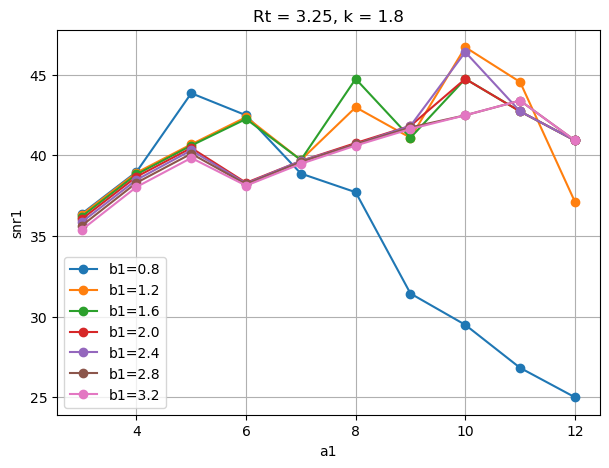

In [3]:
# 你自己填范围
a1_range = np.round(np.arange(3.0, 13.0, 1), 2)
b1_range = np.round(np.arange(0.8, 3.6, 0.4), 2)

df_fig5_like = scan_a1_b1_lines(
    Rt=2.25,
    k=1.0,
    a2=3.0,
    b2=1.0,
    a1_range=a1_range,
    b1_range=b1_range,
    snr_key="snr1",   # 一般这个模块先画 snr1
    n_repeats=1
)

plot_a1_b1_lines(
    df_fig5_like,
    snr_key="snr1",
    title="Rt = 3.25, k = 1.8"
)

[0.00055718]
SNR of 1 symbols is 32.537636 dB
[0.00026861]
SNR of 2 symbols is 35.707631 dB
[0.00048846]
SNR of t symbols is 33.109587 dB
BER = 3.332194e-01
[0.00056481]
SNR of 1 symbols is 32.478489 dB
[5.34079009e-05]
SNR of 2 symbols is 42.723713 dB
[0.0004396]
SNR of t symbols is 33.567533 dB
BER = 3.332194e-01
[0.00058314]
SNR of 1 symbols is 32.339733 dB
[1.83107983e-05]
SNR of 2 symbols is 47.372848 dB
[0.00044418]
SNR of t symbols is 33.522493 dB
BER = 3.332194e-01
[0.00057398]
SNR of 1 symbols is 32.408558 dB
[7.62943819e-06]
SNR of 2 symbols is 51.175041 dB
[0.00043502]
SNR of t symbols is 33.613044 dB
BER = 3.332194e-01
[0.00058009]
SNR of 1 symbols is 32.362554 dB
[0.00035562]
SNR of 2 symbols is 34.488537 dB
[0.00052816]
SNR of t symbols is 32.770024 dB
BER = 3.332194e-01
[0.00057398]
SNR of 1 symbols is 32.408558 dB
[0.00026098]
SNR of 2 symbols is 35.832855 dB
[0.00049915]
SNR of t symbols is 33.015528 dB
BER = 3.332194e-01
[0.0005755]
SNR of 1 symbols is 32.397012 dB
[1

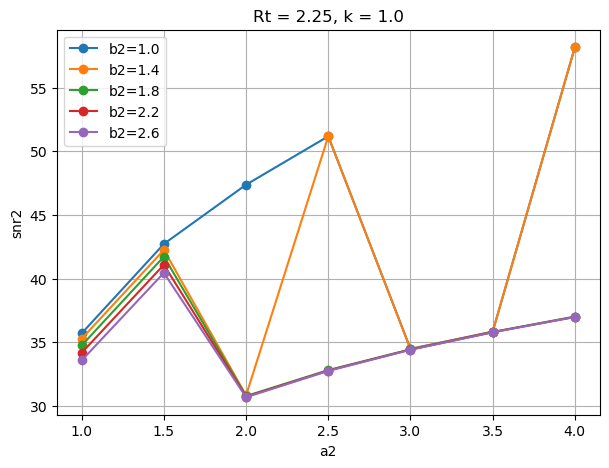

    a2   b2       snr2
0  4.0  1.0  58.164788
1  4.0  1.4  58.164788
2  1.5  1.8  41.729762
3  1.5  2.2  41.088506
4  1.5  2.6  40.455595


In [4]:
a2_range = np.round(np.arange(1.0, 4.1, 0.5), 2)
b2_range = np.round(np.arange(1.0, 2.7, 0.4), 2)

df_fig5_like_n2 = scan_a2_b2_lines(
    Rt=2.25,
    k=1.0,
    a1=2.0,
    b1=4.0,
    a2_range=a2_range,
    b2_range=b2_range,
    snr_key="snr2",
    n_repeats=1
)

plot_a2_b2_lines(
    df_fig5_like_n2,
    snr_key="snr2",
    title="Rt = 2.25, k = 1.0"
)

best_per_b2 = print_best_per_b2(df_fig5_like_n2, snr_key="snr2")

[0.00083976]
SNR of 1 symbols is 30.754790 dB
[0.0003541]
SNR of 2 symbols is 34.507228 dB
[0.0007206]
SNR of t symbols is 31.419902 dB
BER = 3.332194e-01
[0.00058009]
SNR of 1 symbols is 32.362554 dB
[0.00035562]
SNR of 2 symbols is 34.488537 dB
[0.00052816]
SNR of t symbols is 32.770024 dB
BER = 3.332194e-01
[0.00050831]
SNR of 1 symbols is 32.936494 dB
[0.00035715]
SNR of 2 symbols is 34.469926 dB
[0.00047472]
SNR of t symbols is 33.233587 dB
BER = 3.332194e-01
[0.0004793]
SNR of 1 symbols is 33.191860 dB
[0.0003602]
SNR of 2 symbols is 34.432942 dB
[0.00045334]
SNR of t symbols is 33.433789 dB
BER = 3.332194e-01
[0.00046403]
SNR of 1 symbols is 33.332537 dB
[1.37330516e-05]
SNR of 2 symbols is 48.622270 dB
[0.0003541]
SNR of t symbols is 34.507228 dB
BER = 3.332194e-01
[0.00045487]
SNR of 1 symbols is 33.419179 dB
[0.00036631]
SNR of 2 symbols is 34.359903 dB
[0.0004396]
SNR of t symbols is 33.567533 dB
BER = 3.332194e-01


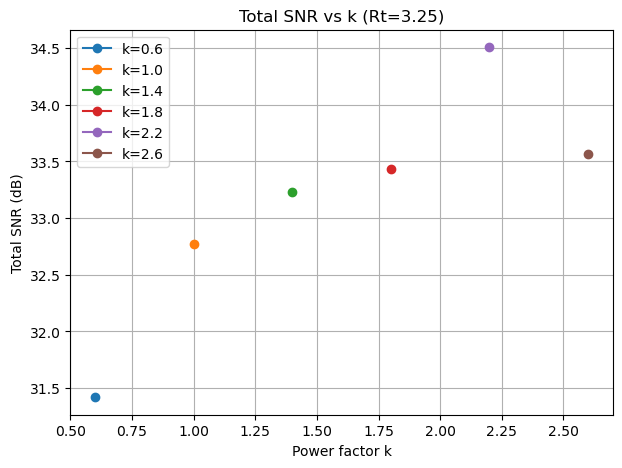

In [53]:
a1 = 2.0
b1 = 4.0
a2 = 3.0
b2 = 1.0
k_range = np.round(np.arange(0.6, 2.7, 0.4), 2)
df_total_SNR_k = scan_total_SNR_k_lines(
    Rt=2.25,
    a1=a1, b1=b1,
    a2=a2, b2=b2,
    k_range=k_range,
    n_repeats=1
)
plot_total_SNR_k_lines(
    df_total_SNR_k,
    title="Total SNR vs k (Rt=3.25)"
)